In [124]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings("ignore")

In [126]:
df=pd.read_csv("Mobiles.csv")

In [128]:
df

,Product Name,Price,Original Price,Discount,Rating,Reviews,Features,Page Number
0,MOTOROLA edge 70 pro (Satin-Luxe PANTONE Tea (...,"₹38,999","₹51,999",25% off,NaN,NaN,8 GB RAM | 256 GB ROM17.27 cm (6.8 inch) Full ...,1
1,MOTOROLA edge 70 pro (Marble - PANTONE Lily wh...,"₹41,999","₹56,999",26% off,NaN,NaN,12 GB RAM | 256 GB ROM17.27 cm (6.8 inch) Full...,1
2,"realme P4 Lite 5G (Mosaic Green, 64 GB)","₹12,999","₹19,999",35% off,4.4,"1,745 Ratings & 89 Reviews",4 GB RAM | 64 GB ROM17.27 cm (6.8 inches) HD+ ...,1
3,"Ai+ Pulse 1 (Sparkle Red, 64 GB)","₹7,999",NaN,NaN,4.3,"49,268 Ratings & 2,888 Reviews",4 GB RAM | 64 GB ROM | Expandable Upto 1 TB17....,1
4,MOTOROLA edge 70 pro (Satin-Luxe PANTONE Tea (...,"₹41,999","₹56,999",26% off,NaN,NaN,12 GB RAM | 256 GB ROM17.27 cm (6.8 inch) Full...,1
...,...,...,...,...,...,...,...,...
979,"OPPO Reno15 Pro Mini 5G (Glacier White, 512 GB)","₹64,999","₹69,999",7% off,4.6,585 Ratings & 94 Reviews,12 GB RAM | 512 GB ROM16.05 cm (6.32 inch) Ful...,41
980,"Nothing Phone (3a) Pro (Grey, 256 GB)","₹31,999","₹34,999",8% off,4.5,"15,174 Ratings & 1,101 Reviews",8 GB RAM | 256 GB ROM43.66 cm (17.19 cm) Full ...,41
981,"Tecno Spark 20 Pro 5G (Glossy White, 128 GB)","₹15,890","₹19,999",20% off,4.1,258 Ratings & 24 Reviews,8 GB RAM | 128 GB ROM | Expandable Upto 1 TB17...,41
982,"Nothing Phone (3a) Pro (Black, 128 GB)","₹29,999","₹32,999",9% off,4.5,"15,174 Ratings & 1,101 Reviews",8 GB RAM | 128 GB ROM43.66 cm (17.19 cm) Full ...,41


#DATA UNDERSTANDINGS

In [131]:
df.head()

,Product Name,Price,Original Price,Discount,Rating,Reviews,Features,Page Number
0,MOTOROLA edge 70 pro (Satin-Luxe PANTONE Tea (...,"₹38,999","₹51,999",25% off,NaN,NaN,8 GB RAM | 256 GB ROM17.27 cm (6.8 inch) Full ...,1
1,MOTOROLA edge 70 pro (Marble - PANTONE Lily wh...,"₹41,999","₹56,999",26% off,NaN,NaN,12 GB RAM | 256 GB ROM17.27 cm (6.8 inch) Full...,1
2,"realme P4 Lite 5G (Mosaic Green, 64 GB)","₹12,999","₹19,999",35% off,4.4,"1,745 Ratings & 89 Reviews",4 GB RAM | 64 GB ROM17.27 cm (6.8 inches) HD+ ...,1
3,"Ai+ Pulse 1 (Sparkle Red, 64 GB)","₹7,999",NaN,NaN,4.3,"49,268 Ratings & 2,888 Reviews",4 GB RAM | 64 GB ROM | Expandable Upto 1 TB17....,1
4,MOTOROLA edge 70 pro (Satin-Luxe PANTONE Tea (...,"₹41,999","₹56,999",26% off,NaN,NaN,12 GB RAM | 256 GB ROM17.27 cm (6.8 inch) Full...,1


In [133]:
df.tail()

,Product Name,Price,Original Price,Discount,Rating,Reviews,Features,Page Number
979,"OPPO Reno15 Pro Mini 5G (Glacier White, 512 GB)","₹64,999","₹69,999",7% off,4.6,585 Ratings & 94 Reviews,12 GB RAM | 512 GB ROM16.05 cm (6.32 inch) Ful...,41
980,"Nothing Phone (3a) Pro (Grey, 256 GB)","₹31,999","₹34,999",8% off,4.5,"15,174 Ratings & 1,101 Reviews",8 GB RAM | 256 GB ROM43.66 cm (17.19 cm) Full ...,41
981,"Tecno Spark 20 Pro 5G (Glossy White, 128 GB)","₹15,890","₹19,999",20% off,4.1,258 Ratings & 24 Reviews,8 GB RAM | 128 GB ROM | Expandable Upto 1 TB17...,41
982,"Nothing Phone (3a) Pro (Black, 128 GB)","₹29,999","₹32,999",9% off,4.5,"15,174 Ratings & 1,101 Reviews",8 GB RAM | 128 GB ROM43.66 cm (17.19 cm) Full ...,41
983,"Tecno Spark 20 Pro 5G (Neon Green, 128 GB)","₹15,880","₹21,999",27% off,4.1,258 Ratings & 24 Reviews,8 GB RAM | 128 GB ROM17.22 cm (6.78 inch) HD+ ...,41


In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Product Name    984 non-null    object 
 1   Price           983 non-null    object 
 2   Original Price  876 non-null    object 
 3   Discount        862 non-null    object 
 4   Rating          740 non-null    float64
 5   Reviews         740 non-null    object 
 6   Features        984 non-null    object 
 7   Page Number     984 non-null    int64  
dtypes: float64(1), int64(1), object(6)
memory usage: 61.6+ KB


In [137]:
df.columns

Index(['Product Name', 'Price', 'Original Price', 'Discount', 'Rating',
       'Reviews', 'Features', 'Page Number'],
      dtype='object')

In [139]:
df.describe()

,Rating,Page Number
count,740.000000,984.000000
mean,4.278108,21.000000
std,0.265125,11.838176
min,3.200000,1.000000
25%,4.100000,11.000000
50%,4.400000,21.000000
75%,4.500000,31.000000
max,5.000000,41.000000


In [141]:
df.describe(include="all")

,Product Name,Price,Original Price,Discount,Rating,Reviews,Features,Page Number
count,984,983,876,862,740.000000,740,984,984.000000
unique,521,270,117,52,NaN,337,411,NaN
top,MOTOROLA edge 70 pro (Satin-Luxe PANTONE Tea (...,"₹38,999","₹56,999",25% off,NaN,"4,835 Ratings & 468 Reviews",8 GB RAM | 256 GB ROM17.27 cm (6.8 inch) Full ...,NaN
freq,80,123,121,141,NaN,40,120,NaN
mean,NaN,NaN,NaN,NaN,4.278108,NaN,NaN,21.000000
std,NaN,NaN,NaN,NaN,0.265125,NaN,NaN,11.838176
min,NaN,NaN,NaN,NaN,3.200000,NaN,NaN,1.000000
25%,NaN,NaN,NaN,NaN,4.100000,NaN,NaN,11.000000
50%,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,21.000000
75%,NaN,NaN,NaN,NaN,4.500000,NaN,NaN,31.000000


In [143]:
df.shape

(984, 8)

In [145]:
 df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Product Name    984 non-null    object 
 1   Price           983 non-null    object 
 2   Original Price  876 non-null    object 
 3   Discount        862 non-null    object 
 4   Rating          740 non-null    float64
 5   Reviews         740 non-null    object 
 6   Features        984 non-null    object 
 7   Page Number     984 non-null    int64  
dtypes: float64(1), int64(1), object(6)
memory usage: 61.6+ KB


In [147]:
df["Discount"].value_counts(normalize=True)*100

Discount
25% off    16.357309
26% off    15.313225
37% off     5.220418
20% off     4.060325
40% off     3.248260
11% off     2.900232
15% off     2.784223
16% off     2.668213
18% off     2.436195
9% off      2.320186
2% off      2.320186
10% off     2.204176
14% off     2.204176
6% off      2.204176
23% off     2.088167
5% off      1.972158
28% off     1.972158
17% off     1.856148
7% off      1.856148
22% off     1.740139
3% off      1.508121
13% off     1.508121
8% off      1.508121
12% off     1.392111
33% off     1.392111
19% off     1.392111
45% off     1.276102
24% off     1.160093
30% off     1.160093
21% off     1.160093
32% off     0.928074
50% off     0.928074
4% off      0.812065
35% off     0.812065
1% off      0.696056
27% off     0.580046
54% off     0.580046
31% off     0.580046
36% off     0.464037
29% off     0.348028
48% off     0.232019
34% off     0.232019
41% off     0.232019
46% off     0.232019
56% off     0.232019
38% off     0.232019
42% off     0.116009
55% 

#DATA CLEANING

In [150]:
df.isnull().sum()

Product Name        0
Price               1
Original Price    108
Discount          122
Rating            244
Reviews           244
Features            0
Page Number         0
dtype: int64

In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Product Name    984 non-null    object 
 1   Price           983 non-null    object 
 2   Original Price  876 non-null    object 
 3   Discount        862 non-null    object 
 4   Rating          740 non-null    float64
 5   Reviews         740 non-null    object 
 6   Features        984 non-null    object 
 7   Page Number     984 non-null    int64  
dtypes: float64(1), int64(1), object(6)
memory usage: 61.6+ KB


In [154]:
df["Rating"].fillna(df["Rating"].mode()[0],inplace=True)

In [156]:
df["Original Price"].fillna(df["Original Price"].mode()[0],inplace=True)

In [158]:
df["Reviews"].fillna(df["Reviews"].mode()[0],inplace=True)

In [160]:
df["Discount"].fillna(df["Discount"].mode()[0],inplace=True)

In [162]:
df["Page Number"].fillna(df["Page Number"].mode()[0],inplace=True)

In [164]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Product Name    984 non-null    object 
 1   Price           983 non-null    object 
 2   Original Price  984 non-null    object 
 3   Discount        984 non-null    object 
 4   Rating          984 non-null    float64
 5   Reviews         984 non-null    object 
 6   Features        984 non-null    object 
 7   Page Number     984 non-null    int64  
dtypes: float64(1), int64(1), object(6)
memory usage: 61.6+ KB


In [166]:
df.isnull().sum()

Product Name      0
Price             1
Original Price    0
Discount          0
Rating            0
Reviews           0
Features          0
Page Number       0
dtype: int64

In [168]:
df.duplicated().sum()

4

In [170]:
df.drop_duplicates(inplace=True)

In [172]:
df.duplicated().sum()

0

In [174]:
df.head(1)

,Product Name,Price,Original Price,Discount,Rating,Reviews,Features,Page Number
0,MOTOROLA edge 70 pro (Satin-Luxe PANTONE Tea (...,"₹38,999","₹51,999",25% off,4.4,"4,835 Ratings & 468 Reviews",8 GB RAM | 256 GB ROM17.27 cm (6.8 inch) Full ...,1


In [176]:
df["Brand"]=df["Product Name"].apply(lambda x:re.findall(r"^\w+",x)[0])

In [178]:
df.head(1)

,Product Name,Price,Original Price,Discount,Rating,Reviews,Features,Page Number,Brand
0,MOTOROLA edge 70 pro (Satin-Luxe PANTONE Tea (...,"₹38,999","₹51,999",25% off,4.4,"4,835 Ratings & 468 Reviews",8 GB RAM | 256 GB ROM17.27 cm (6.8 inch) Full ...,1,MOTOROLA


In [180]:
df["Features"]

0      8 GB RAM | 256 GB ROM17.27 cm (6.8 inch) Full ...
1      12 GB RAM | 256 GB ROM17.27 cm (6.8 inch) Full...
2      4 GB RAM | 64 GB ROM17.27 cm (6.8 inches) HD+ ...
3      4 GB RAM | 64 GB ROM | Expandable Upto 1 TB17....
4      12 GB RAM | 256 GB ROM17.27 cm (6.8 inch) Full...
                             ...                        
979    12 GB RAM | 512 GB ROM16.05 cm (6.32 inch) Ful...
980    8 GB RAM | 256 GB ROM43.66 cm (17.19 cm) Full ...
981    8 GB RAM | 128 GB ROM | Expandable Upto 1 TB17...
982    8 GB RAM | 128 GB ROM43.66 cm (17.19 cm) Full ...
983    8 GB RAM | 128 GB ROM17.22 cm (6.78 inch) HD+ ...
Name: Features, Length: 980, dtype: object

In [182]:
df["Hardware_specs"]=df["Features"].apply(lambda x:re.findall(r"^\w+",x)[0])

In [184]:
df["Hardware_specs"]

0       8
1      12
2       4
3       4
4      12
       ..
979    12
980     8
981     8
982     8
983     8
Name: Hardware_specs, Length: 980, dtype: object

In [186]:
df.head(1)

,Product Name,Price,Original Price,Discount,Rating,Reviews,Features,Page Number,Brand,Hardware_specs
0,MOTOROLA edge 70 pro (Satin-Luxe PANTONE Tea (...,"₹38,999","₹51,999",25% off,4.4,"4,835 Ratings & 468 Reviews",8 GB RAM | 256 GB ROM17.27 cm (6.8 inch) Full ...,1,MOTOROLA,8


In [188]:
df["Ratings1"]=df["Reviews"].apply(lambda x:re.split(r"[&]",x)[0])

In [190]:
df["number_of_ratings"]=df["Ratings1"].apply(lambda x: re.findall(r"[\d,]+",x)[0].replace(",","")).astype("int")

In [192]:
df["Reviews1"]=df["Reviews"].apply(lambda x: re.split(r"[&]",x)[1])

In [194]:
df["number_of_reviews"]=df["Reviews1"].apply(lambda x: re.findall(r"[\d,]+",x)[0].replace(",","")).astype("int")

In [196]:
df["Price"] = df["Price"].apply(
    lambda x: re.sub(r"[₹,]", "", str(x)) if pd.notnull(x) else x
).astype(float).astype("Int64")

In [198]:
df["Original Price"]=df["Original Price"].apply(lambda x:re.sub(r"[₹,]","",x)).astype("int")

In [200]:
df.head(1)

,Product Name,Price,Original Price,Discount,Rating,Reviews,Features,Page Number,Brand,Hardware_specs,Ratings1,number_of_ratings,Reviews1,number_of_reviews
0,MOTOROLA edge 70 pro (Satin-Luxe PANTONE Tea (...,38999,51999,25% off,4.4,"4,835 Ratings & 468 Reviews",8 GB RAM | 256 GB ROM17.27 cm (6.8 inch) Full ...,1,MOTOROLA,8,"4,835 Ratings",4835,468 Reviews,468


In [202]:
df["Discount"]=df["Discount"].apply(lambda x: re.findall(r"\d%+",x)[0])

In [204]:
df["Features"][0]

'8 GB RAM | 256 GB ROM17.27 cm (6.8 inch) Full HD+ Super AMOLED Display50MP + 50MP | 50MP Front Camera6500 mAh Silicon-Carbon BatteryDimensity 8500 Extreme Processor1 Year on Handset and 6 Months on Accessories'

In [206]:
df["RAM(GB)"] = df["Features"].str.extract(r'(\d+)\s*GB\s*RAM', expand=False)
df["RAM"] = df["RAM(GB)"].astype(str) + " GB"

In [208]:
df.head(1)

,Product Name,Price,Original Price,Discount,Rating,Reviews,Features,Page Number,Brand,Hardware_specs,Ratings1,number_of_ratings,Reviews1,number_of_reviews,RAM(GB),RAM
0,MOTOROLA edge 70 pro (Satin-Luxe PANTONE Tea (...,38999,51999,5%,4.4,"4,835 Ratings & 468 Reviews",8 GB RAM | 256 GB ROM17.27 cm (6.8 inch) Full ...,1,MOTOROLA,8,"4,835 Ratings",4835,468 Reviews,468,8,8 GB


In [210]:
df["Camera"] = df["Features"].str.extract(r'((\d+MP.*?Camera))', expand=False)[0]

In [212]:
df.head(1)

,Product Name,Price,Original Price,Discount,Rating,Reviews,Features,Page Number,Brand,Hardware_specs,Ratings1,number_of_ratings,Reviews1,number_of_reviews,RAM(GB),RAM,Camera
0,MOTOROLA edge 70 pro (Satin-Luxe PANTONE Tea (...,38999,51999,5%,4.4,"4,835 Ratings & 468 Reviews",8 GB RAM | 256 GB ROM17.27 cm (6.8 inch) Full ...,1,MOTOROLA,8,"4,835 Ratings",4835,468 Reviews,468,8,8 GB,50MP + 50MP | 50MP Front Camera


In [214]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 980 entries, 0 to 983
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Product Name       980 non-null    object 
 1   Price              979 non-null    Int64  
 2   Original Price     980 non-null    int32  
 3   Discount           980 non-null    object 
 4   Rating             980 non-null    float64
 5   Reviews            980 non-null    object 
 6   Features           980 non-null    object 
 7   Page Number        980 non-null    int64  
 8   Brand              980 non-null    object 
 9   Hardware_specs     980 non-null    object 
 10  Ratings1           980 non-null    object 
 11  number_of_ratings  980 non-null    int32  
 12  Reviews1           980 non-null    object 
 13  number_of_reviews  980 non-null    int32  
 14  RAM(GB)            779 non-null    object 
 15  RAM                980 non-null    object 
 16  Camera             916 non-null

#df.drop(columns=  {"Productname","Features","Review","Ratings1","Reviews1","RAM(GB)"},inplace=True)

In [217]:
df["Rear Camera (MP)"] = pd.to_numeric(df["Features"].str.extract(r'(\d+)\s*MP', expand=False),errors="coerce"
).astype("Int64")

In [219]:
df["Front Camera (MP)"] = pd.to_numeric(
    df["Features"].str.extract(r'\|\s*(\d+)\s*MP\s*Front', expand=False),
    errors="coerce"
).astype("Int64")

In [221]:
df.head(1)

,Product Name,Price,Original Price,Discount,Rating,Reviews,Features,Page Number,Brand,Hardware_specs,Ratings1,number_of_ratings,Reviews1,number_of_reviews,RAM(GB),RAM,Camera,Rear Camera (MP),Front Camera (MP)
0,MOTOROLA edge 70 pro (Satin-Luxe PANTONE Tea (...,38999,51999,5%,4.4,"4,835 Ratings & 468 Reviews",8 GB RAM | 256 GB ROM17.27 cm (6.8 inch) Full ...,1,MOTOROLA,8,"4,835 Ratings",4835,468 Reviews,468,8,8 GB,50MP + 50MP | 50MP Front Camera,50,50


In [223]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 980 entries, 0 to 983
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Product Name       980 non-null    object 
 1   Price              979 non-null    Int64  
 2   Original Price     980 non-null    int32  
 3   Discount           980 non-null    object 
 4   Rating             980 non-null    float64
 5   Reviews            980 non-null    object 
 6   Features           980 non-null    object 
 7   Page Number        980 non-null    int64  
 8   Brand              980 non-null    object 
 9   Hardware_specs     980 non-null    object 
 10  Ratings1           980 non-null    object 
 11  number_of_ratings  980 non-null    int32  
 12  Reviews1           980 non-null    object 
 13  number_of_reviews  980 non-null    int32  
 14  RAM(GB)            779 non-null    object 
 15  RAM                980 non-null    object 
 16  Camera             916 non-null

In [86]:
df

,Product Name,Price,Original Price,Discount,Rating,Reviews,Features,Page Number,Brand,Hardware_specs,Ratings1,number_of_ratings,Reviews1,number_of_reviews
0,MOTOROLA edge 70 pro (Satin-Luxe PANTONE Tea (...,38999,51999,25% off,4.4,"4,835 Ratings & 468 Reviews",8 GB RAM | 256 GB ROM17.27 cm (6.8 inch) Full ...,1,MOTOROLA,8,"4,835 Ratings",4835,468 Reviews,468
1,MOTOROLA edge 70 pro (Marble - PANTONE Lily wh...,41999,56999,26% off,4.4,"4,835 Ratings & 468 Reviews",12 GB RAM | 256 GB ROM17.27 cm (6.8 inch) Full...,1,MOTOROLA,12,"4,835 Ratings",4835,468 Reviews,468
2,"realme P4 Lite 5G (Mosaic Green, 64 GB)",12999,19999,35% off,4.4,"1,745 Ratings & 89 Reviews",4 GB RAM | 64 GB ROM17.27 cm (6.8 inches) HD+ ...,1,realme,4,"1,745 Ratings",1745,89 Reviews,89
3,"Ai+ Pulse 1 (Sparkle Red, 64 GB)",7999,56999,25% off,4.3,"49,268 Ratings & 2,888 Reviews",4 GB RAM | 64 GB ROM | Expandable Upto 1 TB17....,1,Ai,4,"49,268 Ratings",49268,"2,888 Reviews",2888
4,MOTOROLA edge 70 pro (Satin-Luxe PANTONE Tea (...,41999,56999,26% off,4.4,"4,835 Ratings & 468 Reviews",12 GB RAM | 256 GB ROM17.27 cm (6.8 inch) Full...,1,MOTOROLA,12,"4,835 Ratings",4835,468 Reviews,468
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
979,"OPPO Reno15 Pro Mini 5G (Glacier White, 512 GB)",64999,69999,7% off,4.6,585 Ratings & 94 Reviews,12 GB RAM | 512 GB ROM16.05 cm (6.32 inch) Ful...,41,OPPO,12,585 Ratings,585,94 Reviews,94
980,"Nothing Phone (3a) Pro (Grey, 256 GB)",31999,34999,8% off,4.5,"15,174 Ratings & 1,101 Reviews",8 GB RAM | 256 GB ROM43.66 cm (17.19 cm) Full ...,41,Nothing,8,"15,174 Ratings",15174,"1,101 Reviews",1101
981,"Tecno Spark 20 Pro 5G (Glossy White, 128 GB)",15890,19999,20% off,4.1,258 Ratings & 24 Reviews,8 GB RAM | 128 GB ROM | Expandable Upto 1 TB17...,41,Tecno,8,258 Ratings,258,24 Reviews,24
982,"Nothing Phone (3a) Pro (Black, 128 GB)",29999,32999,9% off,4.5,"15,174 Ratings & 1,101 Reviews",8 GB RAM | 128 GB ROM43.66 cm (17.19 cm) Full ...,41,Nothing,8,"15,174 Ratings",15174,"1,101 Reviews",1101


In [225]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 980 entries, 0 to 983
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Product Name       980 non-null    object 
 1   Price              979 non-null    Int64  
 2   Original Price     980 non-null    int32  
 3   Discount           980 non-null    object 
 4   Rating             980 non-null    float64
 5   Reviews            980 non-null    object 
 6   Features           980 non-null    object 
 7   Page Number        980 non-null    int64  
 8   Brand              980 non-null    object 
 9   Hardware_specs     980 non-null    object 
 10  Ratings1           980 non-null    object 
 11  number_of_ratings  980 non-null    int32  
 12  Reviews1           980 non-null    object 
 13  number_of_reviews  980 non-null    int32  
 14  RAM(GB)            779 non-null    object 
 15  RAM                980 non-null    object 
 16  Camera             916 non-null

In [227]:
df.isnull().sum()

Product Name           0
Price                  1
Original Price         0
Discount               0
Rating                 0
Reviews                0
Features               0
Page Number            0
Brand                  0
Hardware_specs         0
Ratings1               0
number_of_ratings      0
Reviews1               0
number_of_reviews      0
RAM(GB)              201
RAM                    0
Camera                64
Rear Camera (MP)      29
Front Camera (MP)    265
dtype: int64

In [229]:
df["Price"].fillna(df["Price"].mode()[0],inplace=True)

In [231]:
df["Camera"].fillna(df["Camera"].mode()[0],inplace=True)

In [233]:
df["Rear Camera (MP)"].fillna(df["Rear Camera (MP)"].mode()[0],inplace=True)

In [362]:
df.replace(["?", "nan GB", "missing"], np.nan, inplace=True)

In [370]:
df.isnull().sum()

Price                0
Original Price       0
Discount             0
Rating               0
Page Number          0
Brand                0
Hardware_specs       0
number_of_ratings    0
number_of_reviews    0
RAM                  0
Camera               0
dtype: int64

In [372]:
df["RAM"].fillna(df["RAM"].mode()[0],inplace=True)

In [374]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 980 entries, 0 to 979
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Price              980 non-null    int64  
 1   Original Price     980 non-null    int64  
 2   Discount           980 non-null    object 
 3   Rating             980 non-null    float64
 4   Page Number        980 non-null    int64  
 5   Brand              980 non-null    object 
 6   Hardware_specs     980 non-null    object 
 7   number_of_ratings  980 non-null    int64  
 8   number_of_reviews  980 non-null    int64  
 9   RAM                980 non-null    object 
 10  Camera             980 non-null    object 
dtypes: float64(1), int64(5), object(5)
memory usage: 84.3+ KB


In [376]:
len(df)
df.index

RangeIndex(start=0, stop=980, step=1)

In [378]:
df = df.reset_index(drop=True)

In [380]:
df

,Price,Original Price,Discount,Rating,Page Number,Brand,Hardware_specs,number_of_ratings,number_of_reviews,RAM,Camera
0,38999,51999,5%,4.4,1,MOTOROLA,8,4835,468,8 GB,50MP + 50MP | 50MP Front Camera
1,41999,56999,6%,4.4,1,MOTOROLA,12,4835,468,12 GB,50MP + 50MP | 50MP Front Camera
2,12999,19999,5%,4.4,1,realme,4,1745,89,4 GB,13MP Rear Camera
3,7999,56999,5%,4.3,1,Ai,4,49268,2888,4 GB,50MP Rear Camera
4,41999,56999,6%,4.4,1,MOTOROLA,12,4835,468,12 GB,50MP + 50MP | 50MP Front Camera
...,...,...,...,...,...,...,...,...,...,...,...
975,64999,69999,7%,4.6,41,OPPO,12,585,94,12 GB,50MP + 50MP | 50MP Front Camera
976,31999,34999,8%,4.5,41,Nothing,8,15174,1101,8 GB,50MP (Main) + 50MP (3X Periscope)+ 8MP (Ultra-...
977,15890,19999,0%,4.1,41,Tecno,8,258,24,8 GB,108MP Rear Camera
978,29999,32999,9%,4.5,41,Nothing,8,15174,1101,8 GB,50MP (Main) + 50MP (3X Periscope)+ 8MP (Ultra-...


In [400]:
df.drop(columns=  {"Product Name","Features","Reviews","Ratings1","Reviews1","RAM(GB)","Rear Camera (MP)","Front Camera (MP)"},inplace=True)

KeyError: "['Rear Camera (MP)', 'Reviews', 'Product Name', 'RAM(GB)', 'Ratings1', 'Features', 'Reviews1', 'Front Camera (MP)'] not found in axis"

In [402]:
df

,Price,Original Price,Discount,Rating,Page Number,Brand,Hardware_specs,number_of_ratings,number_of_reviews,RAM,Camera
0,38999,51999,5%,4.4,1,MOTOROLA,8,4835,468,8 GB,50MP + 50MP | 50MP Front Camera
1,41999,56999,6%,4.4,1,MOTOROLA,12,4835,468,12 GB,50MP + 50MP | 50MP Front Camera
2,12999,19999,5%,4.4,1,realme,4,1745,89,4 GB,13MP Rear Camera
3,7999,56999,5%,4.3,1,Ai,4,49268,2888,4 GB,50MP Rear Camera
4,41999,56999,6%,4.4,1,MOTOROLA,12,4835,468,12 GB,50MP + 50MP | 50MP Front Camera
...,...,...,...,...,...,...,...,...,...,...,...
975,64999,69999,7%,4.6,41,OPPO,12,585,94,12 GB,50MP + 50MP | 50MP Front Camera
976,31999,34999,8%,4.5,41,Nothing,8,15174,1101,8 GB,50MP (Main) + 50MP (3X Periscope)+ 8MP (Ultra-...
977,15890,19999,0%,4.1,41,Tecno,8,258,24,8 GB,108MP Rear Camera
978,29999,32999,9%,4.5,41,Nothing,8,15174,1101,8 GB,50MP (Main) + 50MP (3X Periscope)+ 8MP (Ultra-...


In [382]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 980 entries, 0 to 979
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Price              980 non-null    int64  
 1   Original Price     980 non-null    int64  
 2   Discount           980 non-null    object 
 3   Rating             980 non-null    float64
 4   Page Number        980 non-null    int64  
 5   Brand              980 non-null    object 
 6   Hardware_specs     980 non-null    object 
 7   number_of_ratings  980 non-null    int64  
 8   number_of_reviews  980 non-null    int64  
 9   RAM                980 non-null    object 
 10  Camera             980 non-null    object 
dtypes: float64(1), int64(5), object(5)
memory usage: 84.3+ KB


In [390]:
df.to_csv("cleaned_Mobiles_webscraping.csv",index = False)

In [392]:
df=pd.read_csv("cleaned_Mobiles_webscraping.csv")
df

,Price,Original Price,Discount,Rating,Page Number,Brand,Hardware_specs,number_of_ratings,number_of_reviews,RAM,Camera
0,38999,51999,5%,4.4,1,MOTOROLA,8,4835,468,8 GB,50MP + 50MP | 50MP Front Camera
1,41999,56999,6%,4.4,1,MOTOROLA,12,4835,468,12 GB,50MP + 50MP | 50MP Front Camera
2,12999,19999,5%,4.4,1,realme,4,1745,89,4 GB,13MP Rear Camera
3,7999,56999,5%,4.3,1,Ai,4,49268,2888,4 GB,50MP Rear Camera
4,41999,56999,6%,4.4,1,MOTOROLA,12,4835,468,12 GB,50MP + 50MP | 50MP Front Camera
...,...,...,...,...,...,...,...,...,...,...,...
975,64999,69999,7%,4.6,41,OPPO,12,585,94,12 GB,50MP + 50MP | 50MP Front Camera
976,31999,34999,8%,4.5,41,Nothing,8,15174,1101,8 GB,50MP (Main) + 50MP (3X Periscope)+ 8MP (Ultra-...
977,15890,19999,0%,4.1,41,Tecno,8,258,24,8 GB,108MP Rear Camera
978,29999,32999,9%,4.5,41,Nothing,8,15174,1101,8 GB,50MP (Main) + 50MP (3X Periscope)+ 8MP (Ultra-...


DATA VISUALIZATION

In [328]:
#1. UNIVARIATE ANALYSIS

<Axes: xlabel='Brand'>

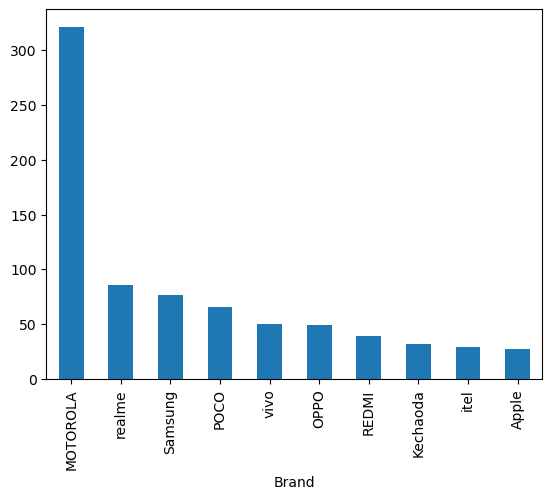

In [394]:
df["Brand"].value_counts().head(10).plot(kind="bar")

<Axes: ylabel='count'>

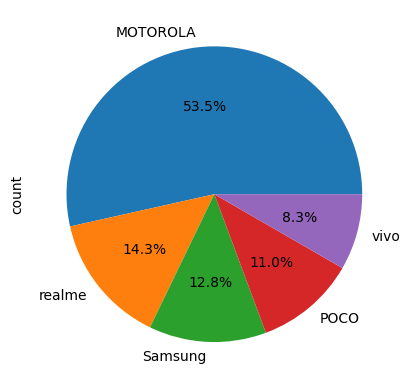

In [258]:
df["Brand"].value_counts().head().plot(kind="pie",autopct="%1.1f%%")

<Axes: xlabel='Price', ylabel='Count'>

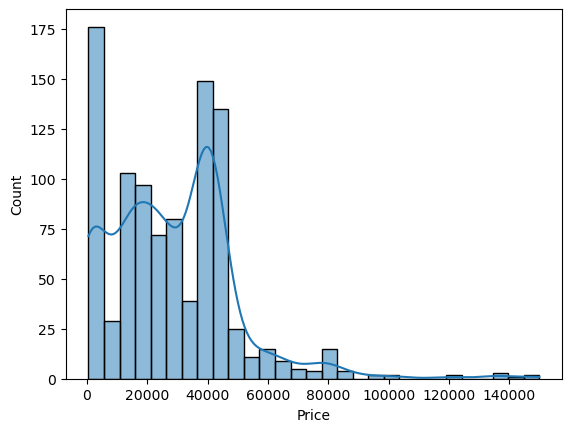

In [260]:
sns.histplot(df["Price"],kde=True) #histplot

<Axes: ylabel='Price'>

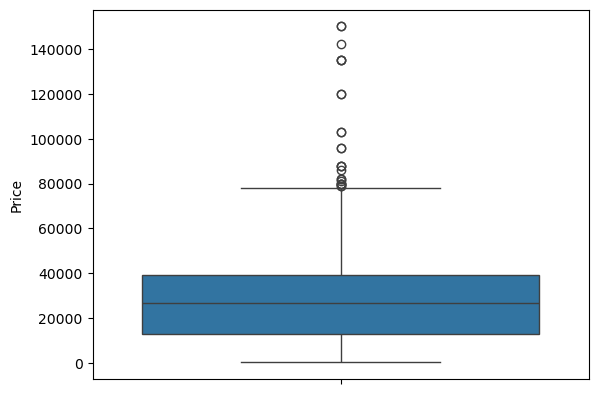

In [262]:
sns.boxplot(df["Price"])

In [398]:
#Outliers
# expensive mobile 
q1=df["Price"].quantile(0.25)
q3=df["Price"].quantile(0.75)
iqr=q3-q1
outliers=df[(df["Price"]<q1-1.5) | (df["Price"]>q3+1.5*iqr)]
outliers

,Price,Original Price,Discount,Rating,Page Number,Brand,Hardware_specs,number_of_ratings,number_of_reviews,RAM,Camera
3,7999,56999,5%,4.3,1,Ai,4,49268,2888,4 GB,50MP Rear Camera
6,777,1499,8%,3.8,1,Jmax,32,243,7,8 GB,1MP Rear Camera
7,1034,1349,3%,4.0,1,Nokia,32,13621,541,8 GB,0MP Front Camera
8,12499,56999,5%,4.2,1,MOTOROLA,4,135639,8095,4 GB,50MP + 8MP | 16MP Front Camera
9,11499,56999,5%,4.2,1,POCO,4,163922,7040,4 GB,50MP Rear Camera
...,...,...,...,...,...,...,...,...,...,...,...
940,980,1599,8%,4.0,40,Kechaoda,32,30980,1660,8 GB,0MP | 0MP Front Camera
941,85999,93999,8%,4.5,40,vivo,16,69,8,16 GB,200MP + 50MP + 50MP | 50MP Front Camera
953,78999,86999,9%,4.6,40,realme,16,97,25,16 GB,50MP + 50MP + 200MP | 32MP Front Camera
959,78999,86999,9%,4.6,41,realme,16,97,25,16 GB,50MP + 50MP + 200MP | 32MP Front Camera


<Axes: xlabel='Brand'>

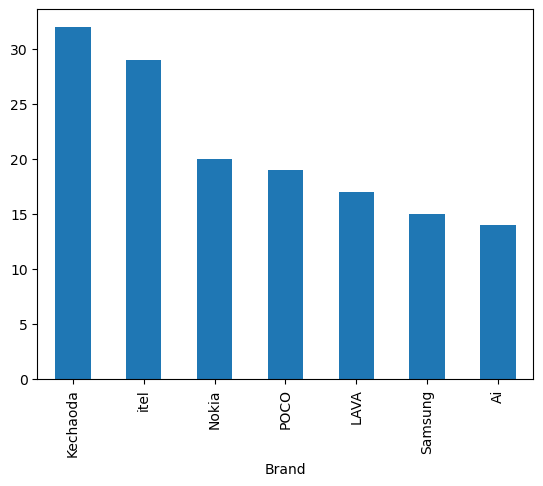

In [274]:
outliers["Brand"].value_counts().head(7).plot(kind="bar")

In [276]:
df.columns

Index(['Price', 'Original Price', 'Discount', 'Rating', 'Page Number', 'Brand',
       'Hardware_specs', 'number_of_ratings', 'number_of_reviews', 'RAM',
       'Camera'],
      dtype='object')

<Axes: xlabel='Rating', ylabel='Price'>

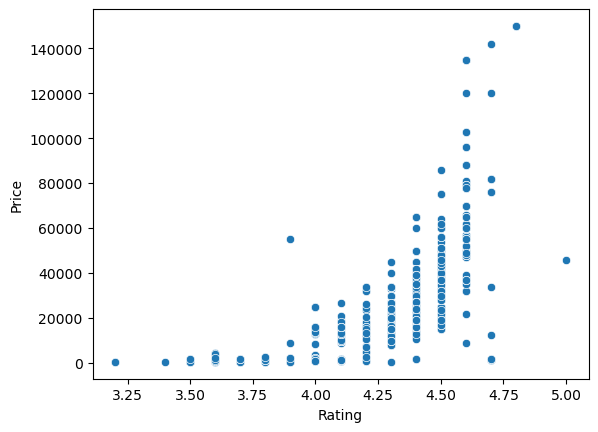

In [356]:
#Price vs Rating
sns.scatterplot(x = "Rating",y = "Price",data =df)

<Axes: xlabel='Price', ylabel='Brand'>

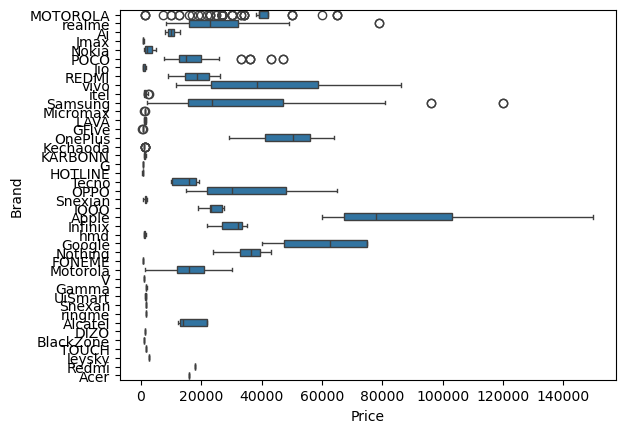

In [286]:
sns.boxplot(x = "Price",y= "Brand",data = df)

<Axes: xlabel='Price', ylabel='Brand'>

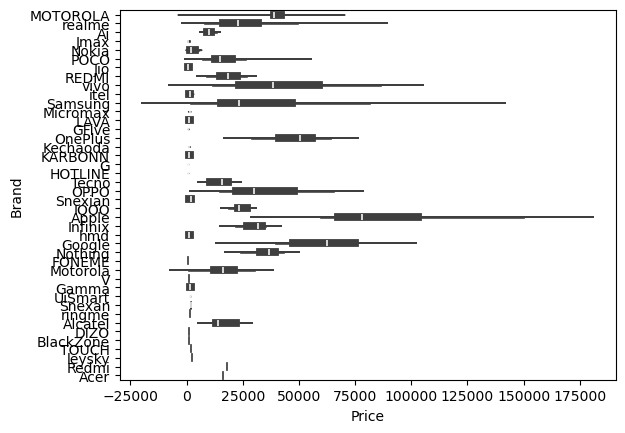

In [290]:
sns.violinplot(x = "Price",y= "Brand",data = df)

In [292]:
# Multivariate Analysis

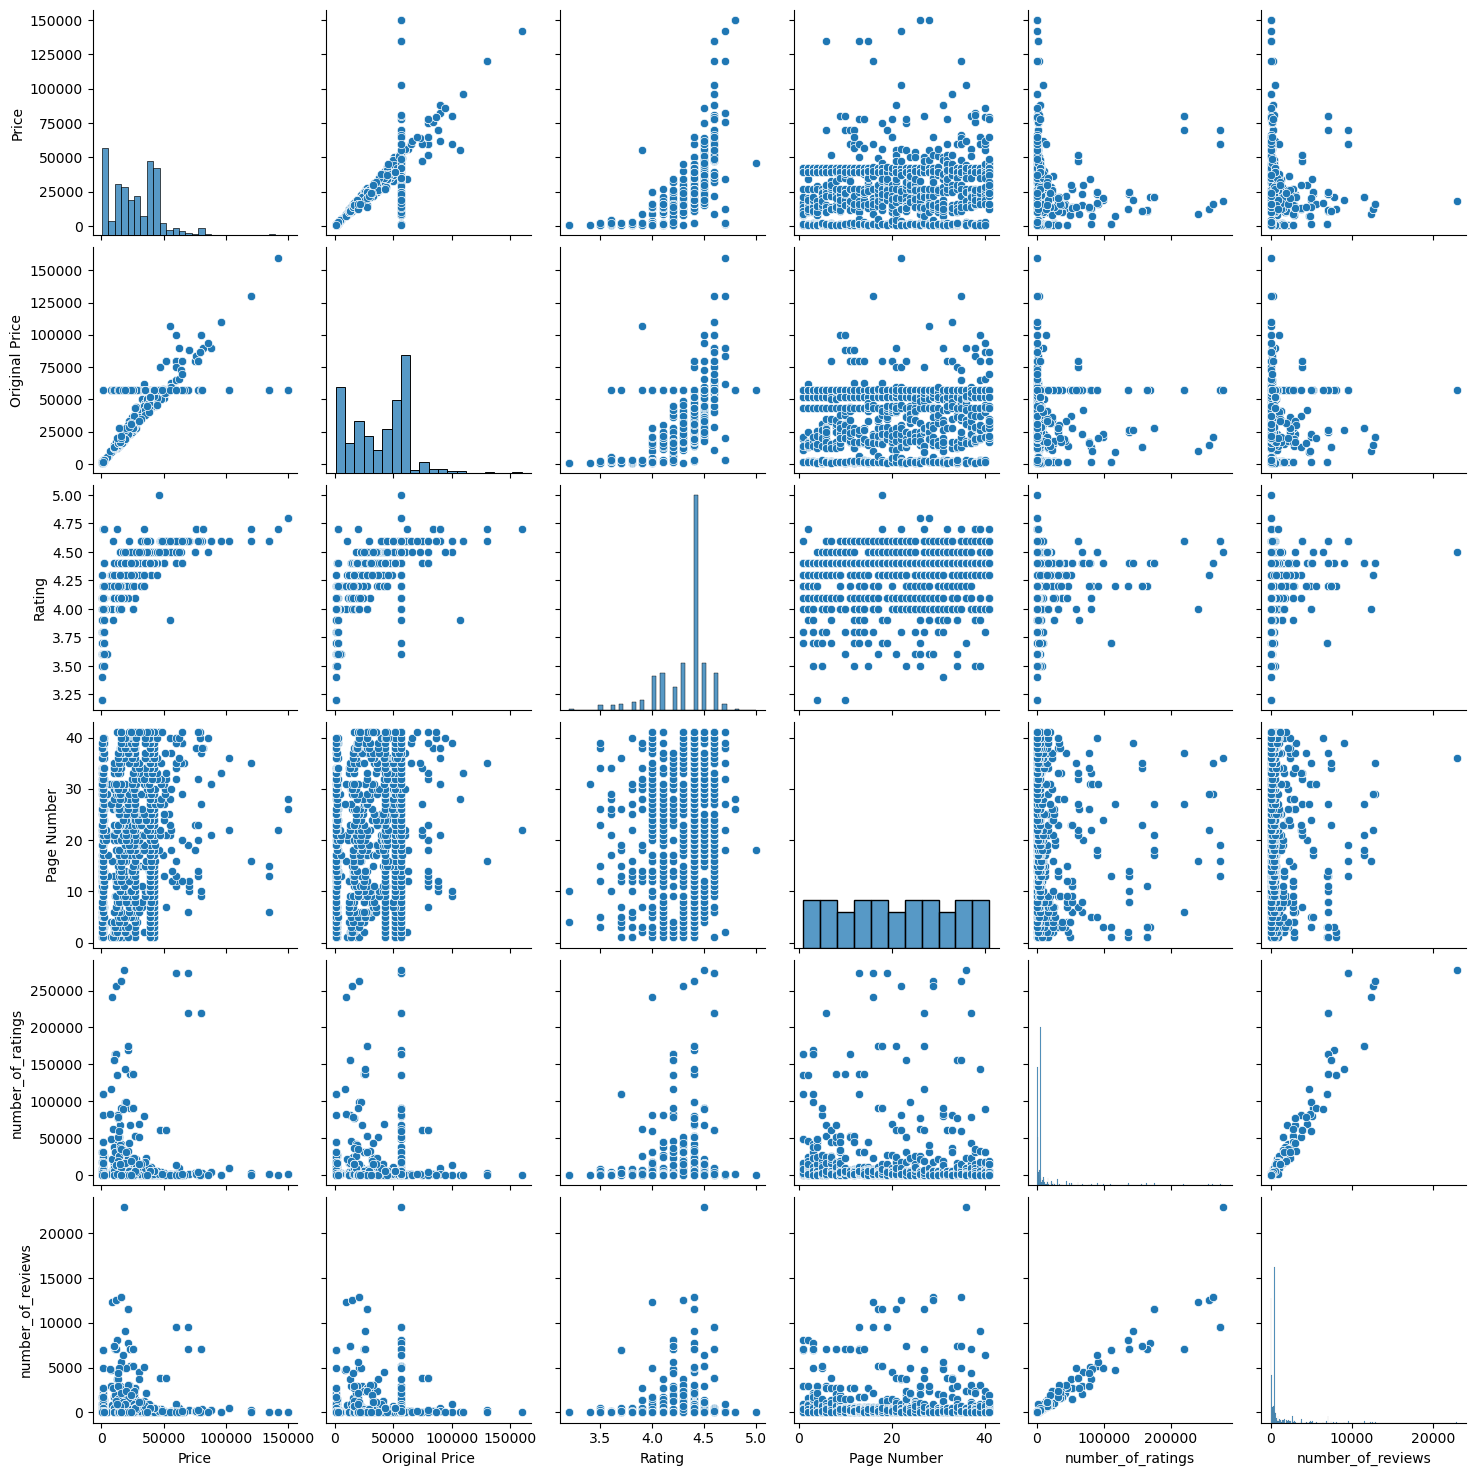

In [294]:
sns.pairplot(df)

In [296]:
#Heatmap

<Axes: >

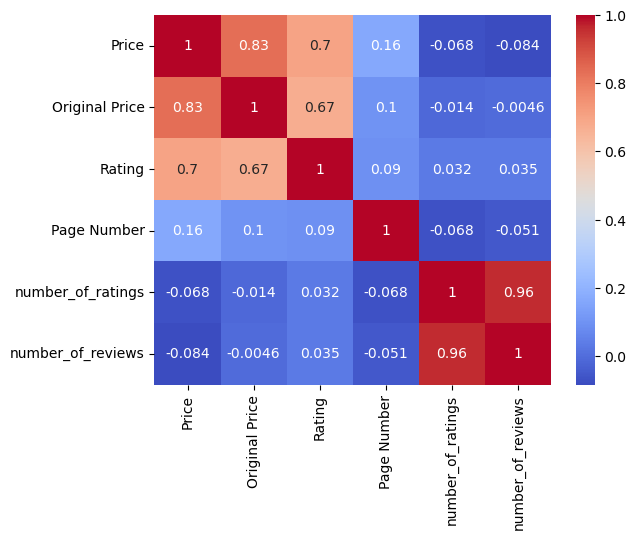

In [300]:
sns.heatmap(df.select_dtypes(include = ["int","float"]).corr(),annot=True,cmap="coolwarm")

In [396]:
df.isnull().sum()

Price                0
Original Price       0
Discount             0
Rating               0
Page Number          0
Brand                0
Hardware_specs       0
number_of_ratings    0
number_of_reviews    0
RAM                  0
Camera               0
dtype: int64